In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))  
sys.path.append(project_root)

In [2]:
from feature_engineering import FeatureExtraction, FeatureExtractionTotal

In [3]:
file_path = "../../data/Expenditure-of-local-bodies.xlsx"
if not os.path.exists(file_path):
    print("File not exist!")
else:
    print("Good to go☺️")

Good to go☺️


In [4]:
import pandas as pd

In [5]:
feature_extraction = FeatureExtraction(fname=file_path) # Default province bagmati
df = feature_extraction.open_file()
df_renamed = feature_extraction.rename_label(dataframe=df)
df_renamed.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,23.587589,15.188281,0.0,38.775871,2.881517


In [6]:
df_renamed.shape

(767, 11)

In [7]:
budget = feature_extraction.extract_budget_frame(dataframe=df_renamed).copy()
print(budget.shape)
budget.head()

(767, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,2.881517


In [8]:
expense = feature_extraction.extract_expenditure_frame(dataframe=df_renamed).copy()
print(expense.shape)
expense.head()

(767, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,23.587589,15.188281,0.0,38.775871,2.881517


In [9]:
budget_total, expense_total = FeatureExtractionTotal(budget_frame=budget, exp_frame=expense).extract_total()
print(budget_total.shape)
print(expense_total.shape)
budget_total.head(8)

Index extracted 😍
Frame for total extracted 😍
Successful 😍
(7, 6)
(7, 6)


,Province,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


In [10]:
budget_sum_province = budget_total[["Province" ,"Total"]].copy()
budget_sum_province.head(8)

,Province,Total
137,Province 1 Total,8966.095518
275,Madesh Province Total,8929.214156
396,Bagmati Province Total,12436.823283
483,Gandaki Province Total,5504.751844
594,Lumbini Province Total,8139.242463
675,Karnali Province Total,4190.658922
765,Sudurpaschim Province Total,5131.579438


In [11]:
import matplotlib.pyplot as plt

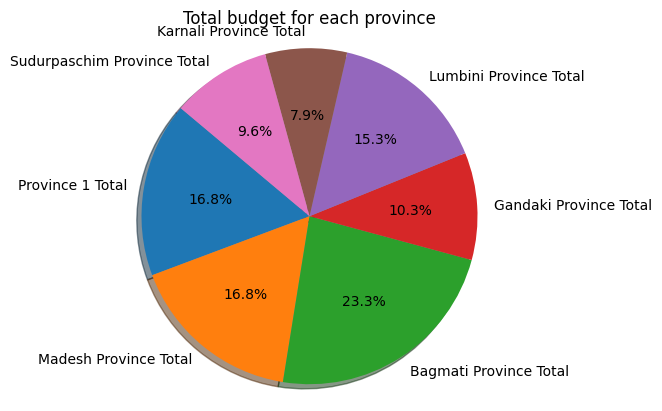

In [12]:
plt.pie(x=budget_sum_province["Total"],
        labels=budget_sum_province["Province"],
        autopct='%1.1f%%',
        startangle=140,
        shadow=True,
        normalize=True)
plt.title("Total budget for each province")
plt.axis('equal')
plt.show()

In [13]:
def plot(dataframe: pd.DataFrame, title: str="budget"):
    plt.pie(x=dataframe["Total"],
        labels=dataframe["Province"],
        autopct='%1.1f%%',
        startangle=140,
        shadow=True,
        normalize=True)
    plt.title(f"Total {title} for each province")
    plt.axis('equal')
    plt.legend()
    plt.show()

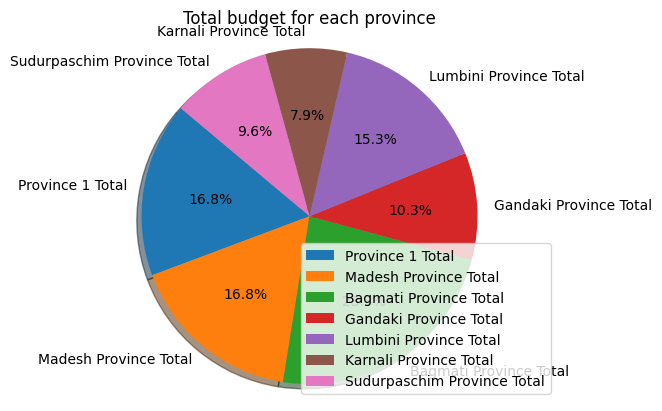

In [14]:
plot(dataframe=budget_sum_province)

In [15]:
expense_sum_province = expense_total[["Province" ,"Total"]].copy()
expense_sum_province.head(8)

,Province,Total
137,Province 1 Total,6710.942339
275,Madesh Province Total,6320.152718
396,Bagmati Province Total,8247.304257
483,Gandaki Province Total,4118.045936
594,Lumbini Province Total,6183.200267
675,Karnali Province Total,3336.573709
765,Sudurpaschim Province Total,4227.409196


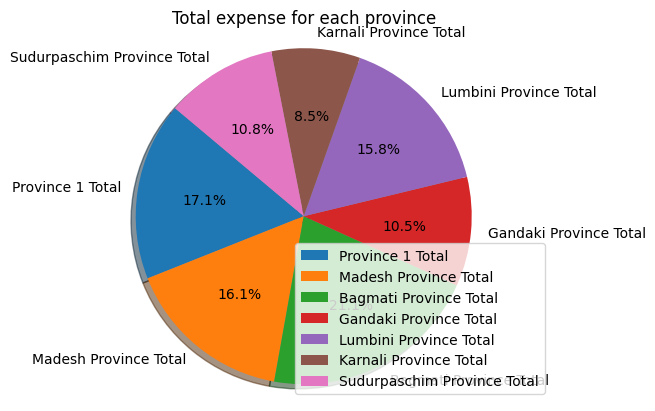

In [16]:
plot(dataframe=expense_sum_province, title='expense')

In [17]:
df_renamed.head(8)

,SN,Local Body,Recurrent,Capital,Financial,Total,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,23.587589,15.188281,0.0,38.775871,2.881517
5,6,Mauwakhola Rural Municipality,21.46895,14.5531,0.0,36.02205,18.164198,13.060848,0.0,31.225046,4.327077
6,7,Pathibhara Yangwarak Rural Municipality,27.369047,21.029567,0.0,48.398614,23.399494,13.367955,0.0,36.767449,6.686506
7,8,Sidingwa Rural Municipality,30.86315,12.018302,0.0,42.881452,24.468454,9.661338,0.0,34.129792,5.39351


In [18]:
print(expense.shape)
expense.head()

(767, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,23.587589,15.188281,0.0,38.775871,2.881517


In [19]:
find_index = lambda name, dataframe : dataframe[dataframe["Local Body"] == name].index[0] 

In [20]:
print(expense["Local Body"].unique())

['Phungling Municipality' 'Aathrai Tribeni Rural Municipality'
 'Phaktanglung  Rural Municipality' 'Mikwakhola  Rural Municipality'
 'Meringdeng Rural Municipality' 'Mauwakhola Rural Municipality'
 'Pathibhara Yangwarak  Rural Municipality' 'Sidingwa  Rural Municipality'
 'Sirijangha  Rural Municipality' 'Phidim Municipality'
 'Kummayak Rural Municipality' 'Tumwewa Rural Municipality'
 'Falelung Rural Municipality' 'Phalgunanad Rural Municipality'
 'Miklajung Rural Municipality' 'Yangwarak  Rural Municipality'
 'Hilihang Rural Municipality' 'Illam Municipality' 'Deumai Municipality'
 'Mai Municipality' 'Shuryodaya Municipality'
 'Chulachuli Rural Municipality' 'Phakphokthum Rural Municipality'
 'Maigokmai Rural Municipality' 'Mangsebung Rural Municipality'
 'Rong Rural Municipality' 'Sandakpur Rural Municipality'
 'Khandwari Municipality' 'Chainpur Municipality'
 'Dharmadevi Municipality' 'Panchkhapan Municipality' 'Madi Municipality'
 'Chichila Rural Municipality' 'Bhotkhola Rural Mun

In [21]:
idx = find_index(name="Mangsebung Rural Municipality", dataframe=expense)
idx

np.int64(24)

In [22]:
exp_for_rm = expense.iloc[24].copy()
exp_for_rm.head()

SN                                       25
Local Body    Mangsebung Rural Municipality
Recurrent                         24.085857
Capital                           11.467076
Financial                               0.0
Name: 24, dtype: object

In [23]:
labels = ['Recurrent', 'Capital', 'Financial', 'Cash Balance']
x = []
for name in labels:
    value = exp_for_rm[name]
    x.append(value)

x

[24.085856741999997, 11.467076191, 0.0, 7.295824593000001]

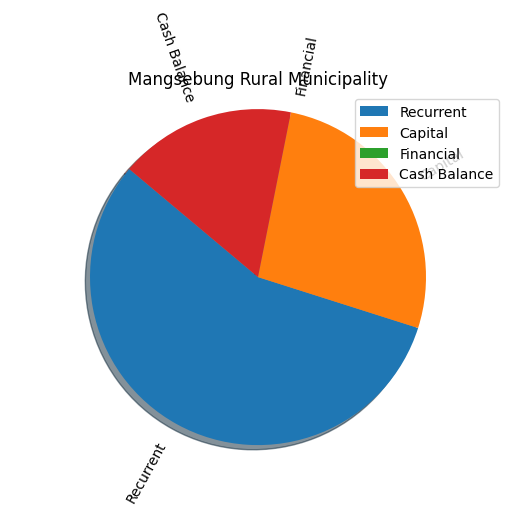

In [24]:
plt.pie(x=x,
        labels=labels,
        startangle=140,
        shadow=True,
        normalize=True,
        rotatelabels=True)
plt.title(f"{exp_for_rm["Local Body"]}")
plt.axis('equal')
plt.legend()
plt.show()

In [25]:
exp_for_rm

SN                                         25
Local Body      Mangsebung Rural Municipality
Recurrent                           24.085857
Capital                             11.467076
Financial                                 0.0
Total                               35.552933
Cash Balance                         7.295825
Name: 24, dtype: object

### Testing implementation 

In [26]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  
sys.path.append(project_root)

In [27]:
from visualization import PieCharts

In [28]:
pie_charts = PieCharts(expense_frame=expense,
                       budget_frame=budget,
                       expense_total=expense_total,
                       budget_total=budget_total)

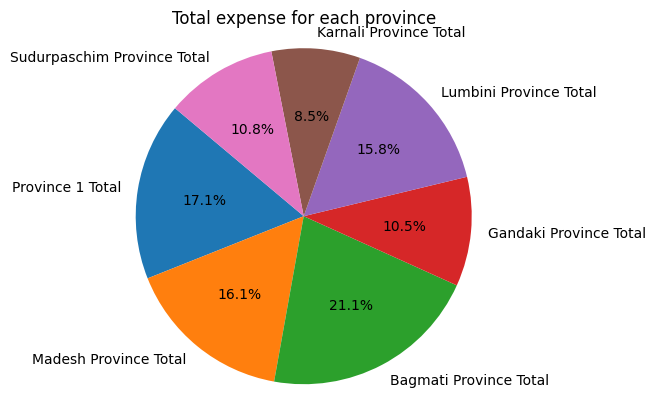

In [32]:
pie_charts.plot_for_total(type='expense') 

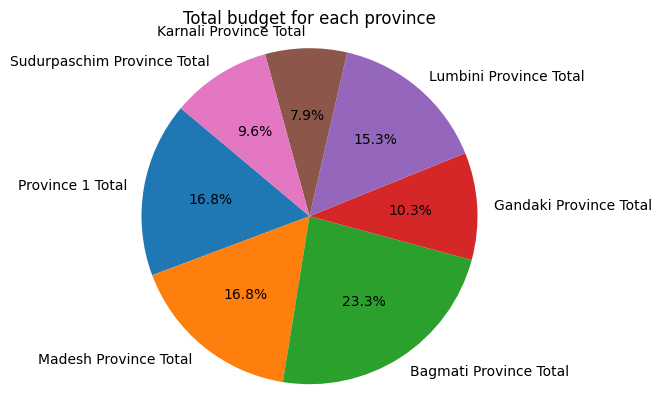

In [33]:
pie_charts.plot_for_total(type='budget')  

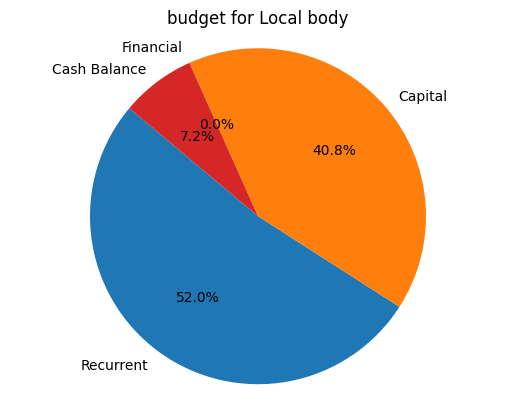

In [35]:
pie_charts.plot_for_local_body(local_body="Guthichaur Rural Municipality")

### Working fine